In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn
import re
import unicodedata


In [2]:
sales = pd.read_csv('sales_train.csv')
items = pd.read_csv('items.csv')
categories = pd.read_csv('item_categories.csv')
shops = pd.read_csv('shops.csv')
test = pd.read_csv('test.csv')

Проведем первичный анализ датасета. EDA

In [3]:
# Начнем с таблицы продаж
print(sales.info())
print(sales.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   date            object 
 1   date_block_num  int64  
 2   shop_id         int64  
 3   item_id         int64  
 4   item_price      float64
 5   item_cnt_day    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 134.4+ MB
None
         date  date_block_num  shop_id  item_id  item_price  item_cnt_day
0  02.01.2013               0       59    22154       999.0           1.0
1  03.01.2013               0       25     2552       899.0           1.0
2  05.01.2013               0       25     2552       899.0          -1.0


In [4]:
print('Уникальных дат: ', sales['date'].nunique())
print('Количество магазинов: ', sales['shop_id'].nunique())
print('Количество итемов: ', sales['item_id'].nunique())
print('Диапазон дат: ', sales['date'].min(), sales['date'].max())
print('Диапозон цен: ', sales['item_price'].min(), sales['item_price'].max())

Уникальных дат:  1034
Количество магазинов:  60
Количество итемов:  21807
Диапазон дат:  01.01.2013 31.12.2014
Диапозон цен:  -1.0 307980.0


In [5]:
print(sales[sales['item_price'] <= 0]) # Обнаружили строку с некорректным значением цены, удалим ее из датасета.
sales_clean = sales[sales['item_price'] > 0]

              date  date_block_num  shop_id  item_id  item_price  item_cnt_day
484683  15.05.2013               4       32     2973        -1.0           1.0


In [6]:
print(sales[sales['item_cnt_day'] < 0].head(3)) # Строки соответствующие возврату товара, являются корректными данными, но надо учитывать эту особенность датасета в будущем

           date  date_block_num  shop_id  item_id  item_price  item_cnt_day
2    05.01.2013               0       25     2552       899.0          -1.0
148  23.01.2013               0       25     2321       999.0          -1.0
175  07.01.2013               0       25     2199      1449.0          -1.0


# Займемся анализом магазинов

In [7]:
# Перейдем к таблице магазинов.
print(shops) # Видим артефакты: знаки препинания в начале и конце строк (0 и 1 строки, 10 и 11 строки)
# Одинаковые магазины под разными id, например 10 и 11.

                                          shop_name  shop_id
0                     !Якутск Орджоникидзе, 56 фран        0
1                     !Якутск ТЦ "Центральный" фран        1
2                                  Адыгея ТЦ "Мега"        2
3                    Балашиха ТРК "Октябрь-Киномир"        3
4                          Волжский ТЦ "Волга Молл"        4
5                            Вологда ТРЦ "Мармелад"        5
6                        Воронеж (Плехановская, 13)        6
7                            Воронеж ТРЦ "Максимир"        7
8                      Воронеж ТРЦ Сити-Парк "Град"        8
9                                 Выездная Торговля        9
10                       Жуковский ул. Чкалова 39м?       10
11                       Жуковский ул. Чкалова 39м²       11
12                              Интернет-магазин ЧС       12
13                              Казань ТЦ "Бехетле"       13
14                          Казань ТЦ "ПаркХаус" II       14
15                      

In [8]:
# Объедим одинаковые де-факто магазины
shop_mapping = {57: 0, 58: 1, 11: 10, 40: 39}
shops['shop_id'] = shops['shop_id'].replace(shop_mapping)
sales['shop_id'] = sales['shop_id'].replace(shop_mapping)
shops = shops.drop_duplicates(subset = 'shop_id', keep='first')
shops = shops.sort_values('shop_id').reset_index(drop=True)

def clean(names):
    names = str(names)
    names = re.sub(r'[!?\^&#$@\*\.\(\);]', '', names)
    names = names.strip()
    names = re.sub(r'\s+', ' ', names)
    return names
    

shops['shop_name'] = shops['shop_name'].apply(clean) # Привели названия магазинов к нормальному виду
print(shops.head(5))

                        shop_name  shop_id
0    Якутск Орджоникидзе, 56 фран        0
1    Якутск ТЦ "Центральный" фран        1
2                Адыгея ТЦ "Мега"        2
3  Балашиха ТРК "Октябрь-Киномир"        3
4        Волжский ТЦ "Волга Молл"        4


In [9]:
#print(sales[sales['shop_id'] == 55].head(10))
#print(sales[sales['shop_id'] == 9].head(10))
#print(sales[sales['shop_id'] == 20].head(10))
#print(sales[sales['shop_id'] == 12].head(10))
#print(sales[sales['shop_id'] == 22].head(10))
print("###UNIQUE_ITEMS###")
print(sales[sales['shop_id'] == 55]['item_id'].nunique())
print(sales[sales['shop_id'] == 9]['item_id'].nunique())
print(sales[sales['shop_id'] == 20]['item_id'].nunique())
print(sales[sales['shop_id'] == 12]['item_id'].nunique())
print(sales[sales['shop_id'] == 22]['item_id'].nunique())

print('\n###SALES###\n')
print(len(sales))
print(len(sales[sales['shop_id'] == 55]))
print(len(sales[sales['shop_id'] == 9]))
print(len(sales[sales['shop_id'] == 12]))
print(len(sales[sales['shop_id'] == 22]))
print(len(sales[sales['shop_id'] == 20]))


# у нас примерно 3 миллона записей. Предлагается удалить данные про Цифровой склад и интернет магазин ЧС,
# поскольку это не розничная торговля, а первое вообще является складом. Москва "Распродажа" похоже на обычный магазин.
# Выездную торговлю тоже оставим, но будем иметь в виду.

# удаляем интернет магазин и цифровой склад.
sales = sales[~sales['shop_id'].isin([12,55])]
shops = shops[~shops['shop_id'].isin([12,55])]
shops = shops.reset_index(drop=True)

###UNIQUE_ITEMS###
1985
1404
746
7382
7951

###SALES###

2935849
34769
3751
34694
45434
1792


# Займемся анализом товаров

In [10]:
categories # хотим получить более обобщенные глобальные категории, например "Аксессуары к PS" и "игры к PS", "PS1" и "P2"
# "Книги", "Музыка", "Подарки" и так далее.

items # Здесь не будем чистить названия, пытаясь привести одно и то же к одному id, т.к. все равно будем оперировать в статистике категориями, а не конкретными товарами

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40
...,...,...,...
22165,"Ядерный титбит 2 [PC, Цифровая версия]",22165,31
22166,Язык запросов 1С:Предприятия [Цифровая версия],22166,54
22167,Язык запросов 1С:Предприятия 8 (+CD). Хрустале...,22167,49
22168,Яйцо для Little Inu,22168,62


In [11]:
# Проверим items на некорректные значения

print(items[['item_id', 'item_name', 'item_category_id']].isna().sum()) # нет nan
invalid_ids = items[pd.to_numeric(items['item_id'], errors='coerce').isna()]
print(f"Товары с нечисловыми id: {len(invalid_ids)}")
no_category = items[items['item_category_id'] < 0]
print(f"Товаров без категории: {len(no_category)}")
strange_names = items[(items['item_name'].str.len() > 200) | (items['item_name'].str.len() < 3)]
print(f"Товары с странными названиями: {len(strange_names)}")
print(strange_names) # обнаружили число в названии - надо проверить еще чтобы названия были нечисловые
invalid_names = items[pd.to_numeric(items['item_name'], errors='coerce').isna()]
print(len(invalid_names), len(items['item_name'])) # такое значение ровно одно, это не глобальная проблема.

print(sales[sales['item_id'] == 1073].head(5)) # видим, что товар продается в разных магазинах -> будем считать что все ок и это не опечатка

print(len(items[items['item_category_id'].isin(categories['item_category_id'])])) # все итемы имеют корректную категорию.

item_id             0
item_name           0
item_category_id    0
dtype: int64
Товары с нечисловыми id: 0
Товаров без категории: 0
Товары с странными названиями: 1
     item_name  item_id  item_category_id
1073        42     1073                40
22169 22170
              date  date_block_num  shop_id  item_id  item_price  item_cnt_day
738816  31.08.2013               7       59     1073       399.0           1.0
743722  25.08.2013               7       43     1073       399.0           1.0
746147  28.08.2013               7       44     1073       399.0           1.0
749617  30.08.2013               7       46     1073       399.0           1.0
753804  28.08.2013               7       52     1073       399.0           1.0
22170


In [12]:
# Займемся категориями
categories # посмотрели вручную, что значения полей корректные. Хотелось бы сделать еще более крупные категории сверху. 

# есть странные категории 79, 80. 9 - товар, а не услуга, посмотреть что бывает в 8-ой.


print(len(items[items['item_category_id'].isin([79])]))
items_ids_79 = items[items['item_category_id'].isin([79])]['item_id']
print(items[items['item_category_id'].isin([79])])

items_ids_80 = items[items['item_category_id'].isin([80])]['item_id']
print(len(items[items['item_category_id'].isin([80])]))
print(sales[sales['item_id'].isin(items_ids_80)])

# билеты предлагается удалить, т.к. это разовое мероприятие, которое будет вызывать 

print(items[items['item_category_id'] == 9])
items_ids_9 = items[items['item_category_id'] == 9]['item_id']

print(sales[sales['item_id'].isin(items_ids_9)])# оказывается доставки нет в продажах, так что можно просто удалить категорию как бесполезную.


print(items[items['item_category_id'] == 8])
items_ids_8 = items[items['item_category_id'] == 8]['item_id']
print(sales[sales['item_id'].isin(items_ids_8)])


#ИТОГ: удаляем 8,9,79,80 категории, т.к. либо там нет продаж, либо это билеты на разовое мероприятие, которые мешают нам, либо это не товары.

1
                                  item_name  item_id  item_category_id
17717  Прием денежных средств для 1С-Онлайн    17717                79
6
               date  date_block_num  shop_id  item_id  item_price  \
2561980  29.04.2015              27       34     9254      1100.0   
2561982  29.04.2015              27       34     9250      1300.0   
2561991  29.04.2015              27       34     9246       900.0   
2562286  30.04.2015              27       31     9254      1100.0   
2562287  30.04.2015              27       31     9250      1300.0   
...             ...             ...      ...      ...         ...   
2879973  02.09.2015              32       28     9254      1300.0   
2879974  04.09.2015              32       28     9254      1300.0   
2879975  12.09.2015              32       28     9254      1300.0   
2879976  13.09.2015              32       28     9254      1300.0   
2879977  14.09.2015              32       28     9254      1300.0   

         item_cnt_day  
2

In [13]:
print(f"✅ Товаров: {len(items)}, Продаж: {len(sales)}")

bad_cats = [8, 9, 79, 80]
bad_items_ids = items[items['item_category_id'].isin(bad_cats)]['item_id'].tolist()

bad_items = items[items['item_category_id'].isin(bad_cats)]
items = items[~items['item_category_id'].isin(bad_cats)]
sales = sales[~sales['item_id'].isin(bad_items_ids)]
categories = categories[~categories['item_category_id'].isin(bad_cats)]

print(f"✅ Удалено! Товаров: {len(items)}, Продаж: {len(sales)}")


✅ Товаров: 22170, Продаж: 2866386
✅ Удалено! Товаров: 22142, Продаж: 2854912


# Sales статистика + удаление дубликатов

In [14]:
duplicates = sales.duplicated()
print(f"Дубликатов строк: {duplicates.sum()}")

print(f"\nПропуски в колонках:")
print(sales.isna().sum())

print(f"\nСтатистика по item_price:")
print(sales['item_price'].describe())

print(f"\nСтатистика по item_cnt_day:")
print(sales['item_cnt_day'].describe())

high_price = sales[sales['item_price'] > 100000]
print(f"\nТоваров с ценой > 100 000 руб.: {len(high_price)}")
if len(high_price) > 0:
    print(high_price[['item_price', 'item_cnt_day']].head())

high_qty = sales[sales['item_cnt_day'] > 100]
print(f"\nПродаж с количеством > 100 шт.: {len(high_qty)}")
if len(high_qty) > 0:
    print(high_qty[['item_price', 'item_cnt_day']].head())


before = len(sales)
sales = sales.drop_duplicates()
after = len(sales)

print(f"Удалено полных дубликатов: {before - after}")


Дубликатов строк: 186

Пропуски в колонках:
date              0
date_block_num    0
shop_id           0
item_id           0
item_price        0
item_cnt_day      0
dtype: int64

Статистика по item_price:
count    2.854912e+06
mean     8.863111e+02
std      1.714883e+03
min     -1.000000e+00
25%      2.490000e+02
50%      3.990000e+02
75%      9.990000e+02
max      5.099900e+04
Name: item_price, dtype: float64

Статистика по item_cnt_day:
count    2.854912e+06
mean     1.221568e+00
std      1.709749e+00
min     -1.600000e+01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      5.020000e+02
Name: item_cnt_day, dtype: float64

Товаров с ценой > 100 000 руб.: 0

Продаж с количеством > 100 шт.: 66
         item_price  item_cnt_day
620237  2559.746729         107.0
845690  2521.211982         217.0
845703  2520.730769         104.0
853771  2507.273810         168.0
858692  2534.000000         156.0
Удалено полных дубликатов: 186


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Стиль графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Создаём колонку с выручкой
sales['revenue'] = sales['item_price'] * sales['item_cnt_day']

# Присоединяем категории к продажам (для анализа)
sales_with_cat = sales.merge(
    items[['item_id', 'item_category_id']], 
    on='item_id', 
    how='left'
)
sales_with_cat = sales_with_cat.merge(
    categories, 
    on='item_category_id', 
    how='left'
)

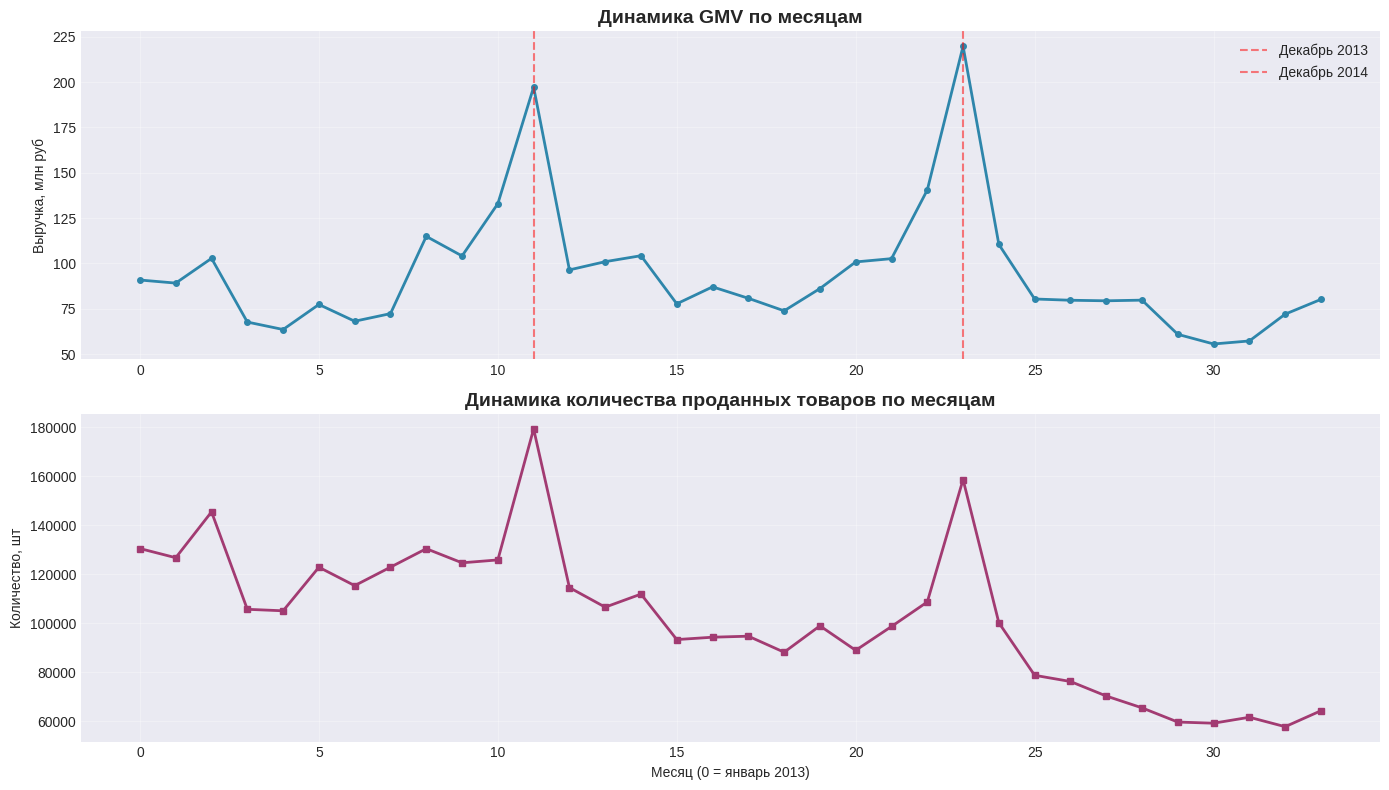

In [16]:
# Агрегируем по месяцам
monthly = sales.groupby('date_block_num').agg({
    'revenue': 'sum',
    'item_cnt_day': 'sum'
}).reset_index()

# Переводим выручку в миллионы
monthly['revenue_million'] = monthly['revenue'] / 1_000_000

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# График выручки
axes[0].plot(monthly['date_block_num'], monthly['revenue_million'], 
             marker='o', linewidth=2, markersize=4, color='#2E86AB')
axes[0].set_title('Динамика GMV по месяцам', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Выручка, млн руб')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=11, color='red', linestyle='--', alpha=0.5, label='Декабрь 2013')
axes[0].axvline(x=23, color='red', linestyle='--', alpha=0.5, label='Декабрь 2014')
axes[0].legend()

# График количества продаж
axes[1].plot(monthly['date_block_num'], monthly['item_cnt_day'], 
             marker='s', linewidth=2, markersize=4, color='#A23B72')
axes[1].set_title('Динамика количества проданных товаров по месяцам', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Месяц (0 = январь 2013)')
axes[1].set_ylabel('Количество, шт')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

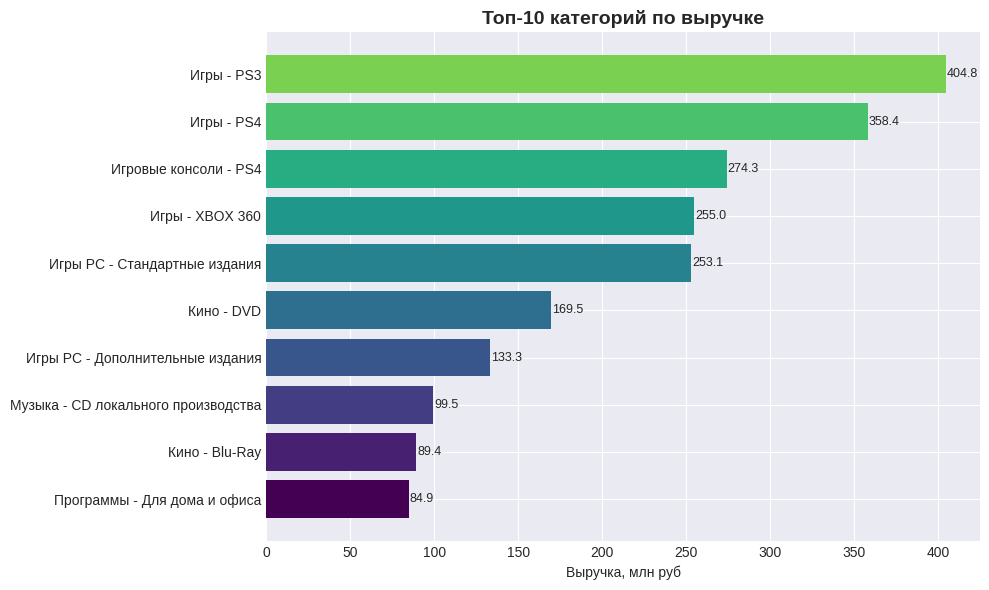

In [17]:
# Агрегируем по категориям
category_revenue = sales_with_cat.groupby('item_category_name')['revenue'].sum().sort_values(ascending=False)

# Берём топ-10
top10_cats = category_revenue.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 0.8, 10))
bars = ax.barh(range(len(top10_cats)), top10_cats.values / 1_000_000, color=colors[::-1])

ax.set_yticks(range(len(top10_cats)))
ax.set_yticklabels([name[:35] for name in top10_cats.index])
ax.set_xlabel('Выручка, млн руб')
ax.set_title('Топ-10 категорий по выручке', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Добавляем значения на столбцы
for i, (bar, val) in enumerate(zip(bars, top10_cats.values / 1_000_000)):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

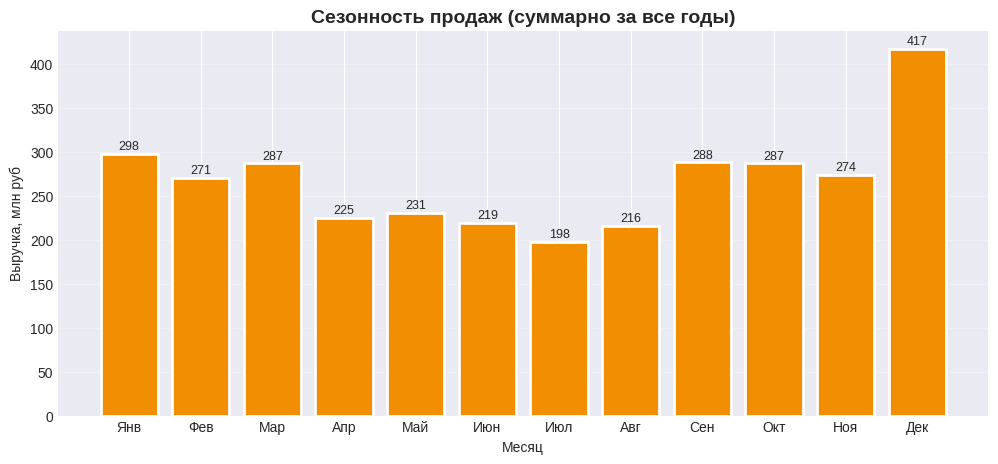

In [18]:
# Добавляем месяц года
sales_with_cat['month_of_year'] = sales_with_cat['date_block_num'] % 12

# Агрегируем по месяцам года
seasonal = sales_with_cat.groupby('month_of_year')['revenue'].sum() / 1_000_000

# Названия месяцев
months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
          'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(months, seasonal.values, color='#F18F01', edgecolor='white', linewidth=2)
ax.set_title('Сезонность продаж (суммарно за все годы)', fontsize=14, fontweight='bold')
ax.set_xlabel('Месяц')
ax.set_ylabel('Выручка, млн руб')
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения
for i, (bar, val) in enumerate(zip(ax.patches, seasonal.values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            f'{val:.0f}', ha='center', fontsize=9)

plt.show()

In [19]:
# Основные метрики
total_revenue = sales['revenue'].sum()
total_items = sales['item_cnt_day'].sum()
avg_price = sales['item_price'].mean()
avg_order_size = sales.groupby(['date', 'shop_id'])['item_cnt_day'].sum().mean()

print("=" * 50)
print("КЛЮЧЕВЫЕ МЕТРИКИ")
print("=" * 50)
print(f"Общая выручка: {total_revenue:,.0f} руб.")
print(f"Общее количество проданных товаров: {total_items:,.0f} шт.")
print(f"Средняя цена товара: {avg_price:.0f} руб.")
print(f"Средний размер чека (в штуках): {avg_order_size:.1f} шт.")
print(f"Всего продаж (строк): {len(sales):,}")
print(f"Уникальных товаров: {sales['item_id'].nunique()}")
print(f"Уникальных магазинов: {sales['shop_id'].nunique()}")

КЛЮЧЕВЫЕ МЕТРИКИ
Общая выручка: 3,208,989,865 руб.
Общее количество проданных товаров: 3,487,229 шт.
Средняя цена товара: 886 руб.
Средний размер чека (в штуках): 77.2 шт.
Всего продаж (строк): 2,854,726
Уникальных товаров: 19612
Уникальных магазинов: 54


In [21]:
sales.to_csv('sales_clean.csv', index=False)
shops.to_csv('shops_clean.csv', index=False)
items.to_csv('items_clean.csv', index=False)
categories.to_csv('categories_clean.csv', index=False)

print("Done")


# Добавим крупные группы, чтобы облегчить построение дашборда


In [33]:
# Создаём полный маппинг категория -> теги
category_tags_mapping = [
    # Аксессуары (8 категорий)
    ('PC - Гарнитуры/Наушники', ['Аксессуары']),
    ('Аксессуары - PS2', ['Аксессуары', 'PlayStation']),
    ('Аксессуары - PS3', ['Аксессуары', 'PlayStation']),
    ('Аксессуары - PS4', ['Аксессуары', 'PlayStation']),
    ('Аксессуары - PSP', ['Аксессуары', 'PlayStation']),
    ('Аксессуары - PSVita', ['Аксессуары', 'PlayStation']),
    ('Аксессуары - XBOX 360', ['Аксессуары', 'XBOX']),
    ('Аксессуары - XBOX ONE', ['Аксессуары', 'XBOX']),
    
    # Консоли (8 категорий)
    ('Игровые консоли - PS2', ['Консоль', 'PlayStation']),
    ('Игровые консоли - PS3', ['Консоль', 'PlayStation']),
    ('Игровые консоли - PS4', ['Консоль', 'PlayStation']),
    ('Игровые консоли - PSP', ['Консоль', 'PlayStation']),
    ('Игровые консоли - PSVita', ['Консоль', 'PlayStation']),
    ('Игровые консоли - XBOX 360', ['Консоль', 'XBOX']),
    ('Игровые консоли - XBOX ONE', ['Консоль', 'XBOX']),
    ('Игровые консоли - Прочие', ['Консоль']),
    
    # Консольные игры (7 категорий)
    ('Игры - PS2', ['Консольные игры', 'PlayStation']),
    ('Игры - PS3', ['Консольные игры', 'PlayStation']),
    ('Игры - PS4', ['Консольные игры', 'PlayStation']),
    ('Игры - PSP', ['Консольные игры', 'PlayStation']),
    ('Игры - PSVita', ['Консольные игры', 'PlayStation']),
    ('Игры - XBOX 360', ['Консольные игры', 'XBOX']),
    ('Игры - XBOX ONE', ['Консольные игры', 'XBOX']),
    
    # Игры - Аксессуары для игр
    ('Игры - Аксессуары для игр', ['Аксессуары', 'Игры']),
    
    # PC игры (6 категорий)
    ('Игры Android - Цифра', ['PC игры', 'Цифровая версия']),
    ('Игры MAC - Цифра', ['PC игры', 'Цифровая версия']),
    ('Игры PC - Дополнительные издания', ['PC игры', 'Физический носитель']),
    ('Игры PC - Коллекционные издания', ['PC игры', 'Физический носитель']),
    ('Игры PC - Стандартные издания', ['PC игры', 'Физический носитель']),
    ('Игры PC - Цифра', ['PC игры', 'Цифровая версия']),
    
    # Карты оплаты (5 категорий)
    ('Карты оплаты (Кино, Музыка, Игры)', ['Карты оплаты', 'Цифровая версия']),
    ('Карты оплаты - Live!', ['Карты оплаты', 'Цифровая версия']),
    ('Карты оплаты - Live! (Цифра)', ['Карты оплаты', 'Цифровая версия']),
    ('Карты оплаты - PSN', ['Карты оплаты', 'Цифровая версия', 'PlayStation']),
    ('Карты оплаты - Windows (Цифра)', ['Карты оплаты', 'Цифровая версия']),
    
    # Кино (5 категорий)
    ('Кино - Blu-Ray', ['Кино', 'Физический носитель']),
    ('Кино - Blu-Ray 3D', ['Кино', 'Физический носитель']),
    ('Кино - Blu-Ray 4K', ['Кино', 'Физический носитель']),
    ('Кино - DVD', ['Кино', 'Физический носитель']),
    ('Кино - Коллекционное', ['Кино', 'Физический носитель']),
    
    # Книги (13 категорий)
    ('Книги - Артбуки, энциклопедии', ['Книги', 'Физический носитель']),
    ('Книги - Аудиокниги', ['Книги', 'Физический носитель']),
    ('Книги - Аудиокниги (Цифра)', ['Книги', 'Цифровая версия']),
    ('Книги - Аудиокниги 1С', ['Книги', 'Физический носитель']),
    ('Книги - Бизнес литература', ['Книги', 'Физический носитель']),
    ('Книги - Комиксы, манга', ['Книги', 'Физический носитель']),
    ('Книги - Компьютерная литература', ['Книги', 'Физический носитель']),
    ('Книги - Методические материалы 1С', ['Книги', 'Физический носитель']),
    ('Книги - Открытки', ['Книги', 'Физический носитель']),
    ('Книги - Познавательная литература', ['Книги', 'Физический носитель']),
    ('Книги - Путеводители', ['Книги', 'Физический носитель']),
    ('Книги - Художественная литература', ['Книги', 'Физический носитель']),
    ('Книги - Цифра', ['Книги', 'Цифровая версия']),
    
    # Музыка (6 категорий)
    ('Музыка - CD локального производства', ['Музыка', 'Физический носитель']),
    ('Музыка - CD фирменного производства', ['Музыка', 'Физический носитель']),
    ('Музыка - MP3', ['Музыка', 'Цифровая версия']),
    ('Музыка - Винил', ['Музыка', 'Физический носитель']),
    ('Музыка - Музыкальное видео', ['Музыка', 'Физический носитель']),
    ('Музыка - Подарочные издания', ['Музыка', 'Физический носитель']),
    
    # Подарки (12 категорий)
    ('Подарки - Атрибутика', ['Подарки']),
    ('Подарки - Гаджеты, роботы, спорт', ['Подарки']),
    ('Подарки - Мягкие игрушки', ['Подарки']),
    ('Подарки - Настольные игры', ['Подарки']),
    ('Подарки - Настольные игры (компактные)', ['Подарки']),
    ('Подарки - Открытки, наклейки', ['Подарки']),
    ('Подарки - Развитие', ['Подарки']),
    ('Подарки - Сертификаты, услуги', ['Подарки']),
    ('Подарки - Сувениры', ['Подарки']),
    ('Подарки - Сувениры (в навеску)', ['Подарки']),
    ('Подарки - Сумки, Альбомы, Коврики д/мыши', ['Подарки']),
    ('Подарки - Фигурки', ['Подарки']),
    
    # Программы (6 категорий)
    ('Программы - 1С:Предприятие 8', ['Программы', 'Физический носитель']),
    ('Программы - MAC (Цифра)', ['Программы', 'Цифровая версия']),
    ('Программы - Для дома и офиса', ['Программы', 'Физический носитель']),
    ('Программы - Для дома и офиса (Цифра)', ['Программы', 'Цифровая версия']),
    ('Программы - Обучающие', ['Программы', 'Физический носитель']),
    ('Программы - Обучающие (Цифра)', ['Программы', 'Цифровая версия']),
    
    # Носители и расходники (3 категории)
    ('Чистые носители (шпиль)', ['Расходники', 'Физический носитель']),
    ('Чистые носители (штучные)', ['Расходники', 'Физический носитель']),
    ('Элементы питания', ['Расходники']),
]

# Преобразуем в DataFrame
category_tags_list = []
for category, tag_list in category_tags_mapping:
    for tag in tag_list:
        category_tags_list.append({
            'item_category_name': category,
            'tag_name': tag
        })

category_tags_df = pd.DataFrame(category_tags_list)

print(category_tags_df)
category_tags_df = category_tags_df.rename(columns={
    'field1': 'item_category_name',
    'field2': 'tag_name'
})
print(f"Создано связей категория->тег: {len(category_tags_df)}")
print(f"Уникальных категорий: {category_tags_df['item_category_name'].nunique()}")
print(f"Уникальных тегов: {category_tags_df['tag_name'].nunique()}")
category_tags_df.to_csv('category_tags.csv', index=False)

            item_category_name             tag_name
0      PC - Гарнитуры/Наушники           Аксессуары
1             Аксессуары - PS2           Аксессуары
2             Аксессуары - PS2          PlayStation
3             Аксессуары - PS3           Аксессуары
4             Аксессуары - PS3          PlayStation
..                         ...                  ...
141    Чистые носители (шпиль)           Расходники
142    Чистые носители (шпиль)  Физический носитель
143  Чистые носители (штучные)           Расходники
144  Чистые носители (штучные)  Физический носитель
145           Элементы питания           Расходники

[146 rows x 2 columns]
Создано связей категория->тег: 146
Уникальных категорий: 80
Уникальных тегов: 16


In [35]:
print(sales['date'].nunique())


1034
